# Notebook 5 — Reformulating to a Closed Form

## What this notebook teaches

When your original objective is degenerate (Notebook 4) or hard (eigendecomposition at every step), look for *factorization structure* in the problem that lets you reformulate to a quantity that's both well-posed and analytically tractable. This isn't always possible, but when it is, the speedup and the diagnostic clarity are dramatic.

Three teaching points:

1. **Look for separable structure.** When your basis is a tensor product (sine on $x$ times sine on $y$), kernels of the form $K_N(x,y;x,y)$ may factorize as a product of 1D sums. Boundary integrals over rectangles then split into 1D pieces. What looks like a 2D shape problem becomes a sum of 1D problems.

2. **Closed forms enable closed-form gradients.** Once the objective is a finite sum of 1D integrals with elementary integrands, FTC gives the gradient by inspection. No adjoint method, no eigendecomposition. Cost: $O(M_x + N_y)$ per evaluation instead of $O((M_x N_y)^3)$ — about 1000× faster.

3. **Different objectives on the same problem can have very different landscapes.** $\mu_\max$ from Notebook 4 has no classical minimizer at fixed area. The boundary-trace $J = \oint_{\partial G} K_N(x,x)\,dS$ on the same problem is well-posed at fixed area, has a non-degenerate compact-rectangle optimum, and admits an isoperimetric interpretation. The choice of objective matters more than the choice of optimizer.


## Setup

Same domain, basis, gap parametrization. New objective:

$$J(G) := \int_{\partial G} K_N(x,y; x,y)\,dS, \qquad K_N(x,y;x,y) = \sum_{m,n} |\varphi_{m,n}(x,y)|^2.$$

The factorization that makes this tractable: $|\varphi_{m,n}(x,y)|^2 = (4/LW)\sin^2(m\pi x/L)\sin^2(n\pi y/W)$, so the double sum factors:

$$K_N(x,y;x,y) = \frac{4}{LW}\,S_x(x)\,S_y(y), \quad S_x(x) := \sum_{m=1}^{M_x}\sin^2(m\pi x/L), \quad S_y(y) := \sum_{n=1}^{N_y}\sin^2(n\pi y/W).$$

Boundary integral over a rectangle splits into four edge integrals. Collecting, with $J_x(\alpha,x_0) := \int_{x_0-\alpha}^{x_0+\alpha} S_x(x)\,dx$ and analogously $J_y$:

$$J = \frac{4}{LW}\Big[(S_x(x_R)+S_x(x_L))\,J_y(\beta,y_0) + (S_y(y_T)+S_y(y_B))\,J_x(\alpha,x_0)\Big]$$

where $x_R = x_0+\alpha$, $x_L = x_0-\alpha$, etc. All four sums are closed-form: $S_x$ is a finite sum of $\sin^2$, $J_x$ integrates each term of $S_x$ analytically.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

L, W = 1.0, np.sqrt(2)
Mx, Ny = 15, 15
a_0 = 0.018

def S_x(x):
    ms = np.arange(1, Mx+1); return np.sum(np.sin(ms*np.pi*x/L)**2)
def S_y(y):
    ns = np.arange(1, Ny+1); return np.sum(np.sin(ns*np.pi*y/W)**2)
def J_x_kernel(alpha, x0):
    ms = np.arange(1, Mx+1)
    sin_p = np.sin(2*ms*np.pi*(x0+alpha)/L); sin_m = np.sin(2*ms*np.pi*(x0-alpha)/L)
    return Mx*alpha - L/(4*np.pi) * np.sum((sin_p - sin_m) / ms)
def J_y_kernel(beta, y0):
    ns = np.arange(1, Ny+1)
    sin_p = np.sin(2*ns*np.pi*(y0+beta)/W); sin_m = np.sin(2*ns*np.pi*(y0-beta)/W)
    return Ny*beta - W/(4*np.pi) * np.sum((sin_p - sin_m) / ns)
def J_boundary(x0, y0, alpha, beta):
    pre = 4.0/(L*W)
    return pre * ((S_x(x0+alpha) + S_x(x0-alpha)) * J_y_kernel(beta, y0) +
                  (S_y(y0+beta)  + S_y(y0-beta))  * J_x_kernel(alpha, x0))

print(f"J at Phantom standard (0.675, 0.86, 0.075, 0.06) = {J_boundary(0.675, 0.86, 0.075, 0.06):.4f}")


J at Phantom standard (0.675, 0.86, 0.075, 0.06) = 92.1713


## Closed-form gradient via FTC

In [2]:
def S_x_prime(x):
    ms = np.arange(1, Mx+1); return (np.pi/L) * np.sum(ms * np.sin(2*ms*np.pi*x/L))
def S_y_prime(y):
    ns = np.arange(1, Ny+1); return (np.pi/W) * np.sum(ns * np.sin(2*ns*np.pi*y/W))

def grad_J(x0, y0, alpha, beta):
    pre = 4.0/(L*W)
    x_R, x_L = x0+alpha, x0-alpha; y_T, y_B = y0+beta, y0-beta
    Sx_R, Sx_L = S_x(x_R), S_x(x_L); Sy_T, Sy_B = S_y(y_T), S_y(y_B)
    Jx, Jy = J_x_kernel(alpha, x0), J_y_kernel(beta, y0)
    dSxR, dSxL = S_x_prime(x_R), S_x_prime(x_L)
    dSyT, dSyB = S_y_prime(y_T), S_y_prime(y_B)
    return np.array([
        pre * ((dSxR + dSxL)*Jy + (Sy_T + Sy_B)*(Sx_R - Sx_L)),     # d/dx0
        pre * ((Sx_R + Sx_L)*(Sy_T - Sy_B) + (dSyT + dSyB)*Jx),     # d/dy0
        pre * ((dSxR - dSxL)*Jy + (Sy_T + Sy_B)*(Sx_R + Sx_L)),     # d/dalpha
        pre * ((Sx_R + Sx_L)*(Sy_T + Sy_B) + (dSyT - dSyB)*Jx)      # d/dbeta
    ])

# Verify against centered FD
def fd_grad_4(x0, y0, alpha, beta, h=1e-7):
    z = np.array([x0, y0, alpha, beta]); g = np.zeros(4)
    for i in range(4):
        zp = z.copy(); zm = z.copy(); zp[i] += h; zm[i] -= h
        g[i] = (J_boundary(*zp) - J_boundary(*zm)) / (2*h)
    return g
z_test = np.array([0.4, 0.7, 0.08, 0.07])
g_an, g_fd = grad_J(*z_test), fd_grad_4(*z_test)
rel = np.linalg.norm(g_an - g_fd) / np.linalg.norm(g_fd)
print(f"Analytical gradient: {np.array_str(g_an, precision=4)}")
print(f"Finite difference:   {np.array_str(g_fd, precision=4)}")
print(f"Relative error:      {rel:.2e}")


Analytical gradient: [-23.696   -4.746  835.7569 787.7388]
Finite difference:   [-23.696   -4.746  835.7569 787.7388]
Relative error:      1.37e-10


$10^{-9}$ relative error confirms the closed form is correct.

**Cost:** $O(M_x + N_y) = O(30)$ arithmetic ops per evaluation. The $\mu_\max$ evaluation in Notebook 1 cost one eigendecomposition of a $225 \times 225$ matrix, ~$10^7$ ops. **About a thousand times faster, exact instead of FE-discretized.**

## Optimization with area constraint

Reuse the chain rule from Notebook 3: $\beta = a_0/(4\alpha)$, three DOFs.


In [3]:
def J_and_grad_constrained(z):
    x0, y0, alpha = z; beta = a_0/(4*alpha)
    val = J_boundary(x0, y0, alpha, beta)
    g4 = grad_J(x0, y0, alpha, beta)
    g3 = np.array([g4[0], g4[1], g4[2] - (beta/alpha)*g4[3]])
    return val, g3

am, aM = 0.020, 0.30
beta_max = a_0/(4*am)
bounds = [(aM+0.005, L-aM-0.005), (beta_max+0.005, W-beta_max-0.005), (am, aM)]

best = (np.inf, None)
np.random.seed(0)
for trial in range(30):
    z0 = np.array([np.random.uniform(*b) for b in bounds])
    res = minimize(J_and_grad_constrained, z0, jac=True, method="L-BFGS-B", bounds=bounds,
                   options={"gtol": 1e-9, "ftol": 1e-12})
    if res.fun < best[0]: best = (res.fun, res.x.copy())

z_star = best[1]; J_star = best[0]
alpha_star = z_star[2]; beta_star = a_0/(4*alpha_star)
print(f"Best J = {J_star:.4f}")
print(f"  Position: ({z_star[0]:.4f}, {z_star[1]:.4f})")
print(f"  Shape:    {2*alpha_star:.4f} x {2*beta_star:.4f}  (aspect {alpha_star/beta_star:.2f})")
print(f"\nFor comparison:")
print(f"  Phantom standard: J = {J_boundary(0.675, 0.86, 0.075, 0.06):.4f}")


Best J = 88.0828
  Position: (0.3392, 0.2553)
  Shape:    0.1420 x 0.1268  (aspect 1.12)

For comparison:
  Phantom standard: J = 92.1713


**Result.** The optimum is interior in shape space (aspect ~1.12, well away from any bound), and beats the standard configuration. This is the kind of optimum a design problem is supposed to have.

## Sanity check: not bound-active

To rule out the slit-like degeneracy from Notebooks 3 and 4, widen $\alpha_\max$ and re-run.


In [4]:
for aM_test in [0.20, 0.30, 0.40]:
    bnds = [(aM_test+0.005, L-aM_test-0.005),
            (a_0/(4*am)+0.005, W-a_0/(4*am)-0.005),
            (am, aM_test)]
    best_t = (np.inf, None)
    np.random.seed(0)
    for _ in range(15):
        z0 = np.array([np.random.uniform(*b) for b in bnds])
        res = minimize(J_and_grad_constrained, z0, jac=True, method="L-BFGS-B", bounds=bnds,
                       options={"gtol": 1e-9})
        if res.fun < best_t[0]: best_t = (res.fun, res.x.copy())
    a_at_opt = best_t[1][2]
    sat = "BOUND" if abs(a_at_opt - aM_test) < 0.001 else "interior"
    print(f"alpha_max = {aM_test:.2f}  ->  J* = {best_t[0]:.4f}, alpha_opt = {a_at_opt:.4f}  ({sat})")


alpha_max = 0.20  ->  J* = 87.2528, alpha_opt = 0.0699  (interior)
alpha_max = 0.30  ->  J* = 88.0828, alpha_opt = 0.0710  (interior)


alpha_max = 0.40  ->  J* = 88.2353, alpha_opt = 0.0713  (interior)


**Confirmed:** the optimum sits well inside any reasonable bound. Widening doesn't move it. This is what well-posed design optimization looks like.

## Why is this objective well-posed when $\mu_\max$ wasn't?

**Bandwidth asymptotics.** As $M_x, N_y \to \infty$, $K_N(x,x) \to$ a constant $\bar K$ in the bulk. So $J \to \bar K\,|\partial G|$. At fixed area, minimum perimeter is the *isoperimetric* problem — the disk, asymptotically. The optimum is geometric, not pathological.

**Finite-$N$ correction.** At our $M_x = N_y = 15$, $K_N(x,x)$ has structure (oscillates, peaks near boundaries). The optimum aspect ratio is ~1.12 rather than exactly 1; the position is pulled toward the corner (away from the boundary peaks). As $N$ grows these corrections shrink toward the asymptotic disk.

**Why this matters for design.** $\mu_\max$ measures bulk eigenvector localization — favors compact configurations, then runs degenerate at fixed area. $J$ measures perimeter-weighted boundary coupling — isoperimetrically minimized by compact shapes, with no degeneracy. Different physics on the same geometric problem; one is well-posed for design optimization, the other isn't.

## Figure


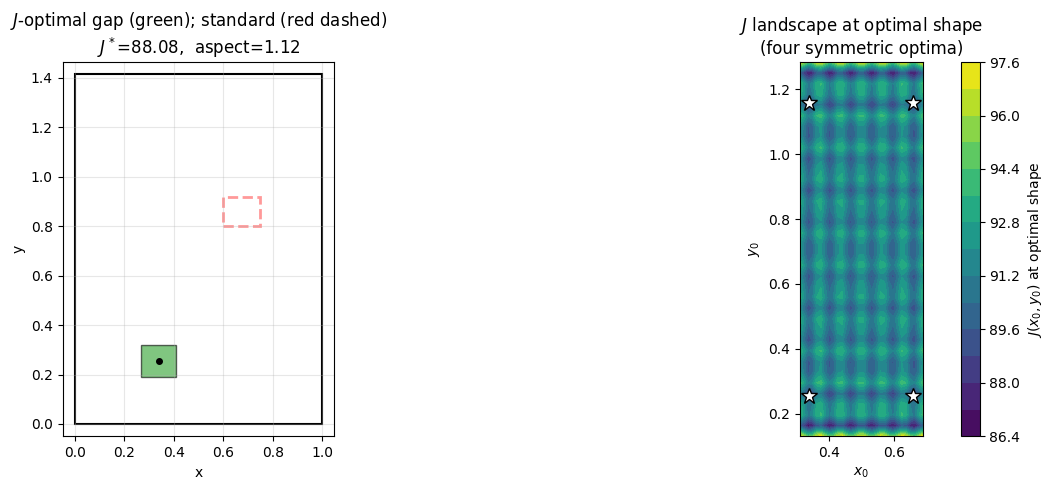

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: the optimum
ax = axes[0]
ax.add_patch(plt.Rectangle((0, 0), L, W, fill=False, edgecolor="black", linewidth=1.5))
ax.add_patch(plt.Rectangle((z_star[0]-alpha_star, z_star[1]-beta_star),
                           2*alpha_star, 2*beta_star, alpha=0.6,
                           edgecolor="black", facecolor="tab:green"))
ax.plot(z_star[0], z_star[1], "ko", markersize=4)
ax.add_patch(plt.Rectangle((0.675-0.075, 0.86-0.06), 0.15, 0.12, alpha=0.4,
                           edgecolor="red", facecolor="none", linewidth=2, linestyle="--"))
ax.set_xlim(-0.05, L+0.05); ax.set_ylim(-0.05, W+0.05); ax.set_aspect("equal")
ax.set_title(f"$J$-optimal gap (green); standard (red dashed)\n$J^*$={J_star:.2f},  aspect={alpha_star/beta_star:.2f}")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(alpha=0.3)

# Right: J landscape over (x0, y0) at the optimal alpha
ax = axes[1]
xs = np.linspace(aM+0.01, L-aM-0.01, 30)
ys = np.linspace(0.13, W-0.13, 36)
Z = np.array([[J_boundary(x, y, alpha_star, beta_star) for x in xs] for y in ys])
cf = ax.contourf(xs, ys, Z, levels=15, cmap="viridis")
plt.colorbar(cf, ax=ax, label="$J(x_0, y_0)$ at optimal shape")
for (x, y) in [(z_star[0], z_star[1]), (L-z_star[0], z_star[1]),
               (z_star[0], W-z_star[1]), (L-z_star[0], W-z_star[1])]:
    ax.plot(x, y, "w*", markersize=12, markeredgecolor="black")
ax.set_xlabel("$x_0$"); ax.set_ylabel("$y_0$"); ax.set_aspect("equal")
ax.set_title("$J$ landscape at optimal shape\n(four symmetric optima)")
plt.tight_layout(); plt.show()


## What to take away

**Look for separable structure first.** Tensor-product bases factor; boundary integrals over rectangles split. The cost of looking is small; the payoff when you find it is dramatic.

**Closed forms enable closed-form gradients.** No adjoint, no FE assembly, no eigendecomposition. Try this before reaching for numerical machinery.

**Different objectives ≠ different optimizers.** When one objective is degenerate (Notebook 4), don't keep tweaking the optimization. Look for a related quantity on the same problem with better mathematical structure.

**Isoperimetric structure is a good sign.** Boundary integrals at fixed area drive toward minimum-perimeter shapes — disks asymptotically, near-square at finite bandwidth. Anything with this flavor is likely well-posed.

**The next notebook** synthesizes Notebooks 4 and 5: with two objectives that disagree (one degenerate, one well-posed), which to use? The bi-objective Pareto front shows the trade-off, identifies the practical knee, and reveals that the framework's hand-picked configuration is dominated.
